# Annotated Transformer
## Declaration（声明）
本文翻译并适度改写自：[The Annotated Transformer](http://nlp.seas.harvard.edu/2018/04/03/attention.html)。

论文 PDF 下载地址：[Attention Is All You Need](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)。


In [1]:
%%bash
# 作用：确保本 notebook 用到的示意图在本地可用。
# 逻辑：如果 images/ 不存在，则从 GitHub 下载 4 张图片；如果已存在则直接跳过。
set -euo pipefail

if [ ! -d images ]; then
  mkdir -p images
  echo "images 文件夹不存在，开始下载图片..."

  base_url="https://raw.githubusercontent.com/SuibeAI/computer_vision_book/main/books/annotated-transformer/images"
  for name in aiayn.png transformer.png scaled_attention.png multi_head.png; do
    wget -q -O "images/${name}" "${base_url}/${name}"
  done

  echo "图片下载完成。"
else
  echo "images 文件夹已存在，跳过下载。"
fi

images 文件夹已存在，跳过下载。


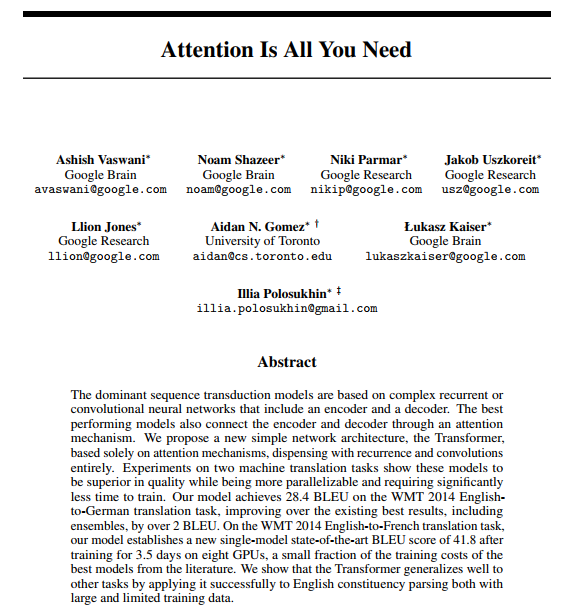

In [2]:
from IPython.display import Image
Image(filename='images/aiayn.png')

In [3]:
# 包导入
import math
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR
import matplotlib.pyplot as plt
from matplotlib import font_manager
import seaborn

seaborn.set_context(context="talk")
%matplotlib inline


def configure_matplotlib_for_chinese():
    """
    为 matplotlib 自动选择可用的中文字体，避免图中中文乱码。
    """
    candidate_fonts = [
        "PingFang SC",
        "Hiragino Sans GB",
        "STHeiti",
        "Heiti SC",
        "Songti SC",
        "Arial Unicode MS",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "SimHei",
        "Microsoft YaHei",
        "WenQuanYi Zen Hei",
    ]
    available_fonts = {f.name for f in font_manager.fontManager.ttflist}
    selected_font = next(
        (font_name for font_name in candidate_fonts if font_name in available_fonts),
        None,
    )
    if selected_font is not None:
        plt.rcParams["font.sans-serif"] = [selected_font] + plt.rcParams.get(
            "font.sans-serif", []
        )
    plt.rcParams["axes.unicode_minus"] = False
    return selected_font


selected_font = configure_matplotlib_for_chinese()
print("matplotlib 中文字体:", selected_font or "未找到候选字体，仍使用默认字体")

matplotlib 中文字体: Hiragino Sans GB


## Transformer简介
Transformer 来自论文《Attention Is All You Need》，提出后受到了广泛关注。它不仅提升了机器翻译质量，也为 NLP 的其他任务提供了新的架构。论文阐述清晰，但完整、正确地实现 Transformer 仍有不少细节需要注意。
这是一个逐行注释的实现版本。我节选了论文中的关键内容，并补充对应代码。完整实现大约 400 行，在 4 张 GPU 上每秒可处理约 27000 个 token。

文档目录结构：

模型结构
- Encoder and Decoder Stacks（编码器和解码器堆栈）：Encoder（编码器）、Decoder（解码器）、Attention（注意力机制）
- Position-wise Feed-Forward Networks（位置逐位前馈网络）
- Embeddings and Softmax（词嵌入和 Softmax）
- Positional Encoding（位置编码）
- Full Model（完整模型）

训练
- Batches and Masking（批处理与掩码）
- Training Loop（训练循环）
- Optimizer（优化器）
- Regularization: Label Smoothing（正则化：标签平滑）

第一个例子
- Synthetic Data（合成数据）
- Loss Computation（损失计算）
- Greedy Decoding（贪婪解码）

可视化

## 背景
Extended Neural GPU、ByteNet 和 ConvS2S 的共同目标之一，是减少序列建模中的顺序计算开销。这些模型都以 CNN 作为构建模块，从而能够并行计算所有输入和输出位置的隐状态表示。在这些模型中，关联两个任意位置的输入所需的计算路径长度会随位置距离增加而增长：ConvS2S 中呈线性增长，ByteNet 中呈对数增长。这使得学习远距离依赖更加困难。Transformer 将这一开销降为常数级。为了弥补单个注意力函数在细粒度模式表达上的不足，论文引入了多头注意力机制（Multi-Head Attention）。


自注意力机制（Self-Attention）有时也称为内部注意力机制（Intra-Attention），它通过关联同一句子中不同位置的信息来生成句子表示。自注意力已经成功应用于阅读理解、摘要、文本蕴含，以及任务无关的句子表示学习等任务。


## 模型结构
多数高性能神经序列转换模型都采用 encoder-decoder 结构。编码器（encoder）将输入序列 $(x_1,\ldots,x_n)$ 映射为连续表示 $\mathbf{z}=(z_1,\ldots,z_n)$；解码器（decoder）再基于 $\mathbf{z}$ 逐步生成输出序列 $(y_1,\ldots,y_m)$。每一步生成都是自回归的，即把前一步的输出作为当前步骤的输入。


In [4]:
class EncoderDecoder(nn.Module):
    """
    标准的编码器-解码器架构。

    Args:
        encoder: 编码器模块，输入形状为 (B, S, D)，输出形状为 (B, S, D)。
        decoder: 解码器模块，输入目标序列形状为 (B, T, D)，编码器记忆形状为 (B, S, D)。
        src_embed: 源序列嵌入模块，输入 token 形状为 (B, S)，输出形状为 (B, S, D)。
        tgt_embed: 目标序列嵌入模块，输入 token 形状为 (B, T)，输出形状为 (B, T, D)。
        generator: 生成器模块，输入形状为 (B, T, D)，输出词表对数概率形状为 (B, T, V)。
    """

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        """
        前向传播，先编码源序列，再解码目标序列。

        Args:
            src: 源序列 token，形状为 (B, S)。
            tgt: 目标序列 token，形状为 (B, T)。
            src_mask: 源序列掩码，形状为 (B, 1, S)。
            tgt_mask: 目标序列掩码，形状为 (B, T, T)。

        Returns:
            解码器输出，形状为 (B, T, D)。
        """
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        """
        编码源序列。

        Args:
            src: 源序列 token，形状为 (B, S)。
            src_mask: 源序列掩码，形状为 (B, 1, S)。

        Returns:
            编码器记忆，形状为 (B, S, D)。
        """
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        """
        基于编码器记忆解码目标序列。

        Args:
            memory: 编码器输出，形状为 (B, S, D)。
            src_mask: 源序列掩码，形状为 (B, 1, S)。
            tgt: 目标序列 token，形状为 (B, T)。
            tgt_mask: 目标序列掩码，形状为 (B, T, T)。

        Returns:
            解码器输出，形状为 (B, T, D)。
        """
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)

In [5]:
class Generator(nn.Module):
    """
    将隐藏状态投影到词表空间，并输出对数概率。

    Args:
        d_model: 隐藏状态维度 D。
        vocab: 词表大小 V。
    """

    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        """
        Args:
            x: 解码器隐藏状态，形状为 (B, T, D) 。

        Returns:
            对数概率，形状为 (B, T, V) 。
        """
        return F.log_softmax(self.proj(x), dim=-1)

Transformer 如图所示，在编码器（encoder）和解码器（decoder）中堆叠使用自注意力机制（self-attention）和位置逐位前馈网络（position-wise feed-forward network）。


![](images/transformer.png)

### 编码器和解码器栈（Encoder and Decoder Stacks）
#### 编码器（Encoder）
Encoder 由$N=6$个相同结构的层组成。

In [6]:
class Encoder(nn.Module):
    """
    由 N 个编码器层堆叠而成的编码器。

    Args:
        layer: 单个编码器层，输入输出形状均为 (B, S, D)。
        N: 编码器层数。
    """

    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(N)])
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        """
        Args:
            x: 输入表示，形状为 (B, S, D)。
            mask: 源序列掩码，形状为 (B, 1, S)。

        Returns:
            编码器输出，形状为 (B, S, D)。
        """
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

我们在两个子层之间使用残差连接，并随后采用层归一化。

In [7]:
class LayerNorm(nn.Module):
    """
    层归一化模块，对最后一个维度做标准化。

    Args:
        features: 最后一个维度的大小 D。
        eps: 数值稳定性常数。
    """

    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        """
        Args:
            x: 输入张量，形状为 (..., D)。

        Returns:
            归一化后的张量，形状与 x 相同。
        """
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

每个子层的论文形式为 $\mathrm{LayerNorm}(x + \mathrm{Sublayer}(x))$，其中 $\mathrm{Sublayer}(x)$ 在经过 dropout 后作为残差加回到 $x$。

为了方便残差连接，所有子层和嵌入层都使用相同维度 $d_{model}=512$。

译者注：论文原文采用后归一化（Post-LN）：$\mathrm{LayerNorm}(x + \mathrm{Sublayer}(x))$。本 notebook 沿用 Annotated Transformer 的实现，在编码器层和解码器层中直接展开前归一化形式：先对输入做 LayerNorm，再经过子层与 dropout，最后与残差相加，并在编码器/解码器堆栈末尾再做一次 LayerNorm。

每个编码器层都有两个子层：
- 第一个子层是多头自注意力机制（multi-head self-attention）。
- 第二个子层是简单的位置逐位全连接前馈网络（position-wise fully connected feed-forward network）。


In [8]:
class EncoderLayer(nn.Module):
    """
    单个编码器层，由自注意力子层和前馈网络子层组成。

    为了更直观地展示数据流，这里直接在层内展开
    "先归一化 -> 子层 -> dropout -> 残差相加"。

    Args:
        size: 隐藏维度 D。
        self_attn: 自注意力模块，输入输出形状为 (B, S, D)。
        feed_forward: 前馈网络模块，输入输出形状为 (B, S, D)。
        dropout: dropout 比例。
    """

    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.norm1 = LayerNorm(size)
        self.norm2 = LayerNorm(size)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.size = size

    def forward(self, x, mask):
        """
        Args:
            x: 编码器输入，形状为 (B, S, D)。
            mask: 源序列掩码，形状为 (B, 1, S)。

        Returns:
            编码器层输出，形状为 (B, S, D)。
        """
        norm_x = self.norm1(x)
        x = x + self.dropout1(self.self_attn(norm_x, norm_x, norm_x, mask)) # 第一个子层：自注意力
        x = x + self.dropout2(self.feed_forward(self.norm2(x))) # 第二个子层：前馈网络
        return x

#### 解码器（Decoder）
Decoder 同样由 $N=6$ 个相同结构的层组成。


In [9]:
class Decoder(nn.Module):
    """
    由 N 个解码器层堆叠而成的解码器。

    Args:
        layer: 单个解码器层，输入输出形状为 (B, T, D)。
        N: 解码器层数。
    """

    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = nn.ModuleList([copy.deepcopy(layer) for _ in range(N)])
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        """
        Args:
            x: 目标序列表示，形状为 (B, T, D)。
            memory: 编码器输出，形状为 (B, S, D)。
            src_mask: 源序列掩码，形状为 (B, 1, S)。
            tgt_mask: 目标序列掩码，形状为 (B, T, T)。

        Returns:
            解码器输出，形状为 (B, T, D)。
        """
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

除编码器（Encoder）已有的两个子层外，解码器（Decoder）还插入了第三个子层，用于对编码器输出执行多头注意力。与编码器一样，每个子层都配有残差连接和层归一化。


In [10]:
class DecoderLayer(nn.Module):
    """
    单个解码器层，由目标端自注意力、源目标注意力和前馈网络组成。

    Args:
        size: 隐藏维度 D。
        self_attn: 目标端自注意力模块，输入输出形状为 (B, T, D)。
        src_attn: 源目标注意力模块，输入为 (B, T, D) 与 (B, S, D)，输出为 (B, T, D)。
        feed_forward: 前馈网络模块，输入输出形状为 (B, T, D)。
        dropout: dropout 比例。
    """

    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.norm1 = LayerNorm(size)
        self.norm2 = LayerNorm(size)
        self.norm3 = LayerNorm(size)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self, x, memory, src_mask, tgt_mask):
        """
        Args:
            x: 解码器输入，形状为 (B, T, D)。
            memory: 编码器输出，形状为 (B, S, D)。
            src_mask: 源序列掩码，形状为 (B, 1, S)。
            tgt_mask: 目标序列掩码，形状为 (B, T, T)。

        Returns:
            解码器层输出，形状为 (B, T, D)。
        """
        m = memory
        norm_x = self.norm1(x)
        x = x + self.dropout1(self.self_attn(norm_x, norm_x, norm_x, tgt_mask)) # 自注意力机制
        norm_x = self.norm2(x)
        x = x + self.dropout2(self.src_attn(norm_x, m, m, src_mask)) # 在编码器输出上做注意力
        x = x + self.dropout3(self.feed_forward(self.norm3(x))) # 前馈网络
        return x

我们还修改了解码器栈（decoder stack）中的自注意力（self-attention）子层，防止当前位置关注到后续位置的单词信息，因为这些信息在生成当前 token 时还不可见。


In [11]:
def subsequent_mask(size):
    """
    生成自回归掩码，屏蔽当前位置之后的未来信息。

    这个掩码常用于解码器自注意力。对于位置 i，只允许它看到
    自己以及它之前的位置，不能看到未来位置。

    Args:
        size: 目标序列长度 T。

    Returns:
        布尔掩码，形状为 (1, T, T)。
        值为 True 表示该位置可见，False 表示该位置被屏蔽。
    """
    future_mask = torch.triu(
        torch.ones(1, size, size, dtype=torch.bool),
        diagonal=1,
    )
    return ~future_mask

In [12]:
example_mask = subsequent_mask(5)
print("掩码形状:", example_mask.shape)
print("掩码内容:\n", example_mask[0].int())

掩码形状: torch.Size([1, 5, 5])
掩码内容:
 tensor([[1, 0, 0, 0, 0],
        [1, 1, 0, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1]], dtype=torch.int32)


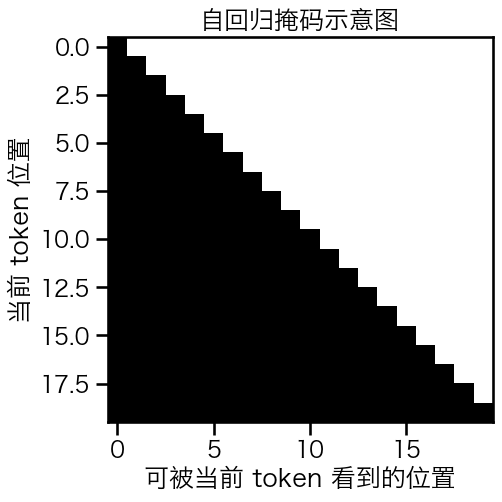

In [13]:
plt.figure(figsize=(5, 5))
plt.imshow(subsequent_mask(20)[0], cmap="Greys")
plt.title("自回归掩码示意图")
plt.xlabel("可被当前 token 看到的位置")
plt.ylabel("当前 token 位置")
None

### 注意力机制（Attention）
注意力机制的核心问题是：当我们生成当前位置的表示时，应该从输入序列的哪些位置取信息、各取多少。
 
它可以看作一种“按相关性做加权求和”的过程：
- 查询（query）表示“当前位置想找什么信息”。
- 键（key）表示“每个位置能提供什么线索”。
- 值（value）表示“每个位置真正要贡献的内容”。
 
模型先比较 query 与各个 key 的相似性，得到一组注意力权重；再用这些权重对对应的 value 做加权求和，得到当前位置的输出表示。

这种注意力形式称为缩放点积注意力（Scaled Dot-Product Attention）。
 
它的计算过程可以分成三步理解：
- 先计算 query 与各个 key 的点积，衡量当前位置与其他位置的相关性。
- 再除以 $\sqrt{d_k}$ 做缩放，避免维度较大时点积数值过大，导致 softmax 过于尖锐。
- 最后对这些分数做 softmax，得到注意力权重，并用这些权重对 value 做加权求和。

![](images/scaled_attention.png)

在实践中，我们会同时处理 query 集合 $Q$、key 集合 $K$ 和 value 集合 $V$，输出定义为：
$$
\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$


In [14]:
def attention(query, key, value, mask=None, dropout=None):
    """
    计算缩放点积注意力。

    Args:
        query: 查询张量，形状为 (B, H, Lq, Dh)。
        key: 键张量，形状为 (B, H, Lk, Dh)。
        value: 值张量，形状为 (B, H, Lk, Dh)。
        mask: 可选掩码。
            编码器自注意力中形状通常为 (B, 1, 1, S)。
            解码器源目标注意力中形状通常为 (B, 1, 1, S)。
            解码器自注意力中形状通常为 (B, 1, T, T)。
        dropout: 可选 dropout 模块。

    Returns:
        output: 注意力输出，形状为 (B, H, Lq, Dh)。
        p_attn: 注意力权重，形状为 (B, H, Lq, Lk)。
    """
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k) # (B, H, Lq, Lk)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    out = torch.matmul(p_attn, value) # (B, H, Lq, Dh)
    return out, p_attn

最常用的两种注意力机制是加性注意力（additive attention）和点积注意力（dot-product attention）。这里采用点积注意力，并使用缩放因子 $\frac{1}{\sqrt{d_k}}$。加性注意力使用单隐层前馈网络计算相似性（compatibility）。虽然两者理论上的计算复杂度相近，但点积注意力在实践中更快、更节省空间，因为它可以高效使用矩阵乘法。


当 $d_k$ 较小时，两种注意力机制效果相近；但当 $d_k$ 增大时，未缩放的点积注意力效果会变差。一个可能原因是点积的数值随维度增大而变大，把 softmax 推到梯度很小的区域。假设 $q$ 和 $k$ 的各维度相互独立，且均值为 0、方差为 1，则点积的均值为 0，方差为 $d_k$，标准差为 $\sqrt{d_k}$。为了减轻这种影响，我们将点积乘以 $\frac{1}{\sqrt{d_k}}$，得到缩放点积注意力。（译者注：更详细解释可参考 [为什么 Transformer 需要进行 Multi-head Attention？](https://kexue.fm/archives/8620)）


In [15]:
def measure_experiment(d=10):
    """
    通过随机实验观察点积及其缩放后的标准差。

    Args:
        d: 向量维度。

    Returns:
        None。函数直接打印实验结果。
    """
    results = []
    for _ in range(10000):
        q = np.random.normal(loc=0.0, scale=1.0, size=(d,))
        k = np.random.normal(loc=0.0, scale=1.0, size=(d,))
        results.append(np.dot(q, k))
    dot_std = np.std(results)
    scaled_dot_std = dot_std / np.sqrt(d)
    print(
        "dimension:{}, dot_std:{:.3f}, scaled_dot_std:{:.3f}".format(
            d, dot_std, scaled_dot_std
        )
    )


measure_experiment(1)
measure_experiment(10)
measure_experiment(100)
measure_experiment(10000)

dimension:1, dot_std:1.016, scaled_dot_std:1.016
dimension:10, dot_std:3.181, scaled_dot_std:1.006
dimension:100, dot_std:10.009, scaled_dot_std:1.001
dimension:10000, dot_std:100.129, scaled_dot_std:1.001


![](images/multi_head.png)

多头注意力机制（Multi-Head Attention）允许模型在不同表示子空间中联合关注不同位置的信息。单头注意力机制难以做到这一点。
$$
\mathrm{MultiHead}(Q,K,V)=\mathrm{Concat}(head_1,\ldots,head_h)W^O
$$
其中：
$$
head_i=\mathrm{Attention}(QW_i^Q,KW_i^K,VW_i^V)
$$
参数维度如下：
$$
W_i^Q \in \mathbb{R}^{d_{model} \times d_k}, W_i^K \in \mathbb{R}^{d_{model} \times d_k}, W_i^V \in \mathbb{R}^{d_{model} \times d_v}, W^O \in \mathbb{R}^{h d_v \times d_{model}}
$$
本文设置 $h=8$，$d_k=d_v=d_{model}/h=64$。由于每个注意力头的维度被缩小，多头注意力的总体计算开销与全维度的单头注意力大致相当。


In [16]:
class MultiHeadAttention(nn.Module):
    """
    多头注意力模块。
    Args:
        h: 注意力头数 H。
        d_model: 模型隐藏维度 D。
        dropout: dropout 比例。
    """

    def __init__(self, h, d_model, dropout=0.1):
        super(MultiHeadAttention, self).__init__()
        assert d_model % h == 0
        self.d_k = d_model // h
        self.h = h
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        """
        Args:
            query: 查询张量，形状为 (B, Lq, D)。
            key: 键张量，形状为 (B, Lk, D)。
            value: 值张量，形状为 (B, Lk, D)。
            mask: 可选掩码。
                编码器自注意力中通常为 (B, 1, S)。
                解码器源目标注意力中通常为 (B, 1, S)。
                解码器自注意力中通常为 (B, T, T)。

        Returns:
            多头拼接并线性映射后的结果，形状为 (B, Lq, D)。
        """
        if mask is not None:
            mask = mask.unsqueeze(1)
        batch_size = query.size(0)

        query = self.w_q(query).view(batch_size, -1, self.h, self.d_k).transpose(1, 2) # (B, Lq, D) -> (B, Lq, H, d_k) -> (B, H, Lq, d_k)
        key = self.w_k(key).view(batch_size, -1, self.h, self.d_k).transpose(1, 2) # (B, Lk, D) -> (B, Lk, H, d_k) -> (B, H, Lk, d_k)
        value = self.w_v(value).view(batch_size, -1, self.h, self.d_k).transpose(1, 2) # (B, Lk, D) -> (B, Lk, H, d_k) -> (B, H, Lk, d_k)

        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        ) # (B, H, Lq, d_k), (B, H, Lq, Lk)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.h * self.d_k)
        return self.w_o(x)

#### 多头注意力机制在模型中的应用
Transformer 以 3 种方式使用 multi-head attention：
1. 在编码器-解码器注意力层（encoder-decoder attention）中，query 来自前一层解码器（decoder）的输出，key 和 value 来自编码器（encoder）的输出。这样，解码器中的每个位置都可以关注输入序列的所有位置。
2. 在编码器（encoder）层中，自注意力层（self-attention）的 query、key 和 value 都来自前一 encoder 层的输出。因此每个位置都可以关注前一层的所有位置。
3. 在解码器（decoder）层中，自注意力机制允许每个位置关注当前位置和之前的位置。为了保持自回归属性，需要阻止信息从未来位置流入当前位置。这里通过在缩放点积注意力（scaled dot-product attention）中使用掩码（mask），屏蔽 softmax 输入中所有无效位置的相似度。


### 位置逐位前馈神经网络层（Position-wise Feed-Forward Networks）
在注意力子层之外，编码器（encoder）和解码器（decoder）的每一层还包含一个独立且相同地应用到各个位置的全连接前馈网络。它由两个线性层和一个 ReLU 激活函数组成：
$$
FFN(x)=\max(0,xW_1+b_1)W_2 + b_2
$$
译者注：位置逐位前馈网络相当于将单隐层 MLP 应用到 $(B,L,D)$ 中每个位置的 $(B,D)$ 表示上，即不同位置的词向量独立使用同一个 MLP。这里 $B$ 表示 batch size，$L$ 表示序列长度，$D$ 表示向量维度。


虽然线性变换在每个位置上相同，但不同层之间的线性变换参数不同。换一种方式描述，它等价于使用两个卷积核大小为 1 的卷积层。输入和输出维度为 $d_{model}=512$，中间层维度为 $d_{ff}=2048$。


In [17]:
class PositionwiseFeedForward(nn.Module):
    """
    位置逐位前馈网络。

    Args:
        d_model: 输入和输出维度 D。
        d_ff: 中间隐藏层维度 Dff。
        dropout: dropout 比例。
    """

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: 输入张量，形状为 (B, L, D)。

        Returns:
            前馈网络输出，形状为 (B, L, D)。
        """
        return self.w_2(self.dropout(self.w_1(x).relu()))

### 词嵌入层（Embeddings）和 Softmax
与大多数序列转换模型类似，我们使用可学习的词嵌入层（embedding）将输入 tokens 和输出 tokens 转换为维度为 $d_{model}$ 的向量。

我们也使用可学习的线性变换和 softmax 函数，将解码器（decoder）的输出转换为下一个 token 的预测概率。在模型中，词嵌入层（embedding）与 pre-softmax 线性变换共享同一个权重矩阵（weight matrix）。

在词嵌入层中，我们将嵌入向量乘以 $\sqrt{d_{model}}$。


In [18]:
class Embeddings(nn.Module):
    """
    词嵌入层，并按论文实现乘以 sqrt(d_model)。

    Args:
        d_model: 嵌入维度 D。
        vocab: 词表大小 V。
    """

    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        """
        Args:
            x: token 索引张量，形状为 (B, L)。

        Returns:
            嵌入结果，形状为 (B, L, D)。
        """
        token_embeddings = self.lut(x)
        scale = math.sqrt(self.d_model)
        return token_embeddings * scale

### 位置编码（Positional Encoding）
由于模型不包含递归或卷积结构，为了让模型利用序列位置信息，必须向 token 表示中注入位置编码。我们将位置编码（positional encoding）加到输入词嵌入向量（embedding）上。位置编码向量与词嵌入向量具有相同维度 $d_{model}$，因此两者可以直接相加。位置编码可以是可学习的，也可以是固定的；这里采用不同频率的正弦和余弦函数：
$$
PE_{pos,2i}=\sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \\
PE_{pos,2i+1}=\cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$
其中 $pos$ 是序列位置，$i$ 是维度索引。也就是说，每个维度对应一条正弦或余弦曲线，其波长构成从 $2\pi$ 到 $10000\cdot2\pi$ 的等比序列。选择这种表示的原因是，它便于模型学习相对位置信息：对于固定偏移 $k$，$PE_{pos+k}$ 可以表示为 $PE_{pos}$ 的线性变换。

此外，我们会对编码器（encoder）栈和解码器（decoder）栈输入端的向量和（词向量 + 位置编码向量）执行 dropout。


#### 思考题
给定正弦位置编码
$$
PE(pos) = [\sin(\omega_1 pos), \cos(\omega_1 pos), \ldots, \sin(\omega_m pos), \cos(\omega_m pos)]
$$
为什么我们常说这种位置编码体现了“位置越近，相似度得分越高”？你可以从两个位置 $pos$ 和 $pos+k$ 的内积随偏移量 $k$ 的变化来思考。

<details>
<summary>点击展开参考答案</summary>

直觉上，当两个位置的间隔很小（偏移量更小）时，各频率分量更容易保持“同相”或接近同相，因此整体相似度更高；当间隔变大时，不同频率分量会逐渐错开，整体相似度通常下降。

这个结论不是严格单调的，但它确实体现了“相对距离小，更容易得到较高相似度”。

</details>

把两个位置的编码做内积：
$$
PE(pos) \cdot PE(pos+k)
$$
对每一对同频率的正弦和余弦分量，有
$$
\sin(a)\sin(b) + \cos(a)\cos(b) = \cos(a-b)
$$
因此同一频率下都有
$$
\sin(\omega_i pos)\sin(\omega_i (pos+k)) + \cos(\omega_i pos)\cos(\omega_i (pos+k)) = \cos(\omega_i k)
$$
把所有维度加起来，可得整体相似度近似只与相对距离 $k$ 有关：
$$
PE(pos) \cdot PE(pos+k) = \sum_i \cos(\omega_i k)
$$
这说明两个位置越接近，也就是 $k$ 越小，所有 $\cos(\omega_i k)$ 越接近 1，内积通常越大；而当距离变大时，不同频率分量会逐渐错开，有的变大、有的变小，整体内积就会下降。

所以，这种位置编码并不是“严格单调”地保证距离越远相似度越低，但它确实让**小偏移对应更高的整体相似性**，并且这种相似性主要由相对距离决定。这也是它适合表达相对位置信息的重要原因。

In [19]:
class PositionalEncoding(nn.Module):
    """
    正弦位置编码。

    Args:
        d_model: 位置编码维度 D。
        dropout: dropout 比例。
        max_len: 支持的最大序列长度。
    """

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        """
        Args:
            x: 输入嵌入，形状为 (B, L, D)。

        Returns:
            加入位置编码后的结果，形状为 (B, L, D)。
        """
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

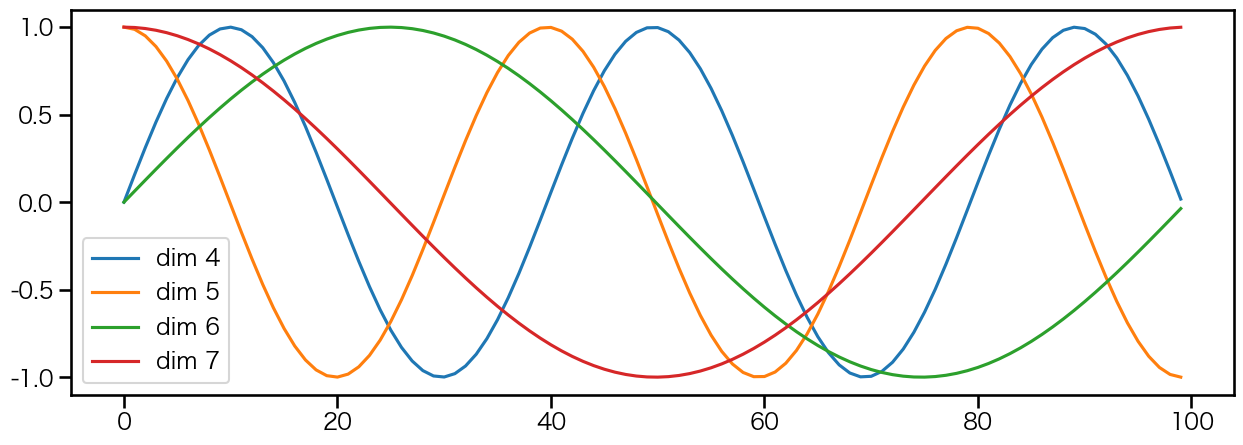

In [20]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(torch.zeros(1, 100, 20))
plt.plot(np.arange(100), y[0, :, 4:8].detach().numpy())
plt.legend(["dim %d" % p for p in [4, 5, 6, 7]])
None


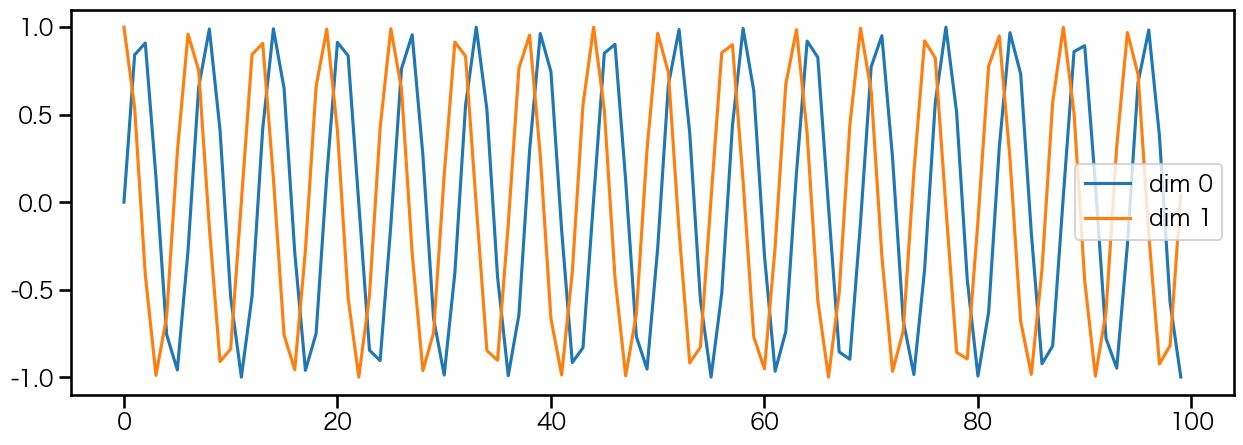

In [21]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(torch.zeros(1, 100, 20))
plt.plot(np.arange(100), y[0, :, 0:2].detach().numpy())
plt.legend(["dim %d" % p for p in [0, 1]])
None


论文中也尝试了可学习的位置嵌入（position embedding），两者效果接近。这里选择正弦位置编码，因为它允许模型在测试时处理比训练序列更长的位置。


### 完整的模型

In [22]:
def make_model(
    src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1
):
    """
    根据超参数构建完整 Transformer。

    Args:
        src_vocab: 源语言词表大小。
        tgt_vocab: 目标语言词表大小。
        N: 编码器和解码器层数。
        d_model: 模型隐藏维度 D。
        d_ff: 前馈层隐藏维度 Dff。
        h: 注意力头数 H。
        dropout: dropout 比例。

    Returns:
        初始化完成的 EncoderDecoder 模型。
    """
    c = copy.deepcopy
    attn = MultiHeadAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

In [23]:
# 构造一个小型示例模型，便于检查网络结构。
tmp_model = make_model(10, 10, 2)
None


## 训练
### Batches and Masking（批处理与掩码）


In [24]:
class Batch:
    """
    训练时使用的小批量数据封装，同时构造源序列和目标序列掩码。

    Args:
        src: 源序列 token，形状为 (B, S)。
        tgt: 目标序列 token，形状为 (B, T)。
        pad: padding token 的索引。
    """

    def __init__(self, src, tgt=None, pad=0):
        self.src = src
        self.src_mask = (src != pad).unsqueeze(-2)
        if tgt is not None:
            self.tgt = tgt[:, :-1]
            self.tgt_y = tgt[:, 1:]
            self.tgt_mask = self.make_std_mask(self.tgt, pad)
            self.ntokens = (self.tgt_y != pad).sum().item()

    @staticmethod
    def make_std_mask(tgt, pad):
        """
        为目标序列构造 padding mask 和后续位置 mask。

        Args:
            tgt: 目标序列输入，形状为 (B, T)。
            pad: padding token 的索引。

        Returns:
            目标序列掩码，形状为 (B, T, T)。
        """
        tgt_mask = (tgt != pad).unsqueeze(-2)
        tgt_mask = tgt_mask & subsequent_mask(tgt.size(-1)).type_as(tgt_mask)
        return tgt_mask


### 训练循环


In [25]:
class DummyOptimizer:
    """评估阶段占位用优化器。"""

    def __init__(self):
        self.param_groups = [{"lr": 0}]

    def step(self):
        return None

    def zero_grad(self, set_to_none=False):
        return None


class DummyScheduler:
    """评估阶段占位用学习率调度器。"""

    def step(self):
        return None


class TrainState:
    """记录训练步数、样本数和 token 数。"""

    step = 0
    accum_step = 0
    samples = 0
    tokens = 0


def run_epoch(
    data_iter,
    model,
    loss_compute,
    optimizer,
    scheduler,
    mode="train",
    accum_iter=1,
    train_state=TrainState(),
):
    """
    执行一个 epoch 的训练或评估。

    Args:
        data_iter: Batch 迭代器。
        model: Transformer 模型。
        loss_compute: 损失计算封装，返回 (loss_value, loss_node)。
        optimizer: 优化器或占位优化器。
        scheduler: 学习率调度器或占位调度器。
        mode: 运行模式，可选为 "train"、"train+log" 或 "eval"。
        accum_iter: 梯度累积步数。
        train_state: 训练状态记录对象。

    Returns:
        平均损失与更新后的训练状态。
    """
    start = time.time()
    total_tokens = 0
    total_loss = 0
    tokens = 0
    n_accum = 0

    for i, batch in enumerate(data_iter):
        out = model.forward(batch.src, batch.tgt, batch.src_mask, batch.tgt_mask)
        loss, loss_node = loss_compute(out, batch.tgt_y, batch.ntokens)

        if mode == "train" or mode == "train+log":
            loss_node.backward()
            train_state.step += 1
            train_state.samples += batch.src.shape[0]
            train_state.tokens += batch.ntokens
            if i % accum_iter == 0:
                optimizer.step()
                optimizer.zero_grad(set_to_none=True)
                n_accum += 1
                train_state.accum_step += 1
            scheduler.step()

        total_loss += loss
        total_tokens += batch.ntokens
        tokens += batch.ntokens

        if i % 40 == 1 and (mode == "train" or mode == "train+log"):
            lr = optimizer.param_groups[0]["lr"]
            elapsed = time.time() - start
            print(
                (
                    "Epoch Step: %6d | Accumulation Step: %3d | Loss: %6.2f "
                    + "| Tokens / Sec: %7.1f | Learning Rate: %6.1e"
                )
                % (i, n_accum, loss / batch.ntokens, tokens / elapsed, lr)
            )
            start = time.time()
            tokens = 0

        del loss
        del loss_node

    return total_loss / total_tokens, train_state

### 优化器
我们采用 Adam 优化器，其中 $\beta_1=0.9$，$\beta_2=0.98$，并且 $\epsilon=10^{-9}$。学习率采用如下计算公式：
$$
lr = d_{model}^{-0.5}\min(step\_num^{-0.5}, step\_num \cdot warmup\_steps^{-1.5})
$$


In [26]:
def rate(step, model_size, factor, warmup):
    """
    按论文公式计算当前 step 对应的学习率缩放值。

    Args:
        step: 当前训练步数。
        model_size: 模型维度 D。
        factor: 额外缩放因子。
        warmup: 预热步数。

    Returns:
        当前 step 的学习率倍率。
    """
    if step == 0:
        step = 1
    return factor * (
        model_size ** (-0.5) * min(step ** (-0.5), step * warmup ** (-1.5))
    )


def get_std_opt(model):
    """
    为模型创建与最新版 Annotated Transformer 一致的优化器和调度器。

    Args:
        model: Transformer 模型。

    Returns:
        (optimizer, lr_scheduler) 二元组。
    """
    optimizer = torch.optim.Adam(
        model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9
    )
    lr_scheduler = LambdaLR(
        optimizer=optimizer,
        lr_lambda=lambda step: rate(
            step,
            model_size=model.src_embed[0].d_model,
            factor=1.0,
            warmup=4000,
        ),
    )
    return optimizer, lr_scheduler

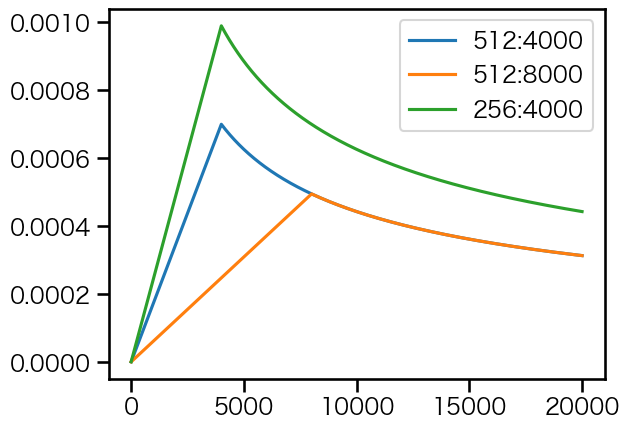

In [27]:
# 三组学习率超参数设置。
opts = [[512, 1, 4000], [512, 1, 8000], [256, 1, 4000]]
plt.plot(
    np.arange(1, 20000),
    [[rate(step, *opt) for opt in opts] for step in range(1, 20000)],
)
plt.legend(["512:4000", "512:8000", "256:4000"])
None

### 正则化
#### 标签平滑
训练过程中使用标签平滑，其中 $\epsilon_{ls}=0.1$。标签平滑会让模型输出保留更多不确定性，因此可能拉高困惑度（perplexity），但通常可以提升准确率和 BLEU 分数。


In [28]:
class LabelSmoothing(nn.Module):
    """
    标签平滑损失。

    Args:
        size: 词表大小 V。
        padding_idx: padding token 的索引。
        smoothing: 平滑系数。
    """

    def __init__(self, size, padding_idx, smoothing=0.0):
        super(LabelSmoothing, self).__init__()
        self.criterion = nn.KLDivLoss(reduction="sum")
        self.padding_idx = padding_idx
        self.confidence = 1.0 - smoothing
        self.smoothing = smoothing
        self.size = size
        self.true_dist = None

    def forward(self, x, target):
        """
        Args:
            x: 模型输出的对数概率，形状为 (N, V)。
            target: 目标标签索引，形状为 (N,)。

        Returns:
            标量损失。
        """
        assert x.size(1) == self.size
        with torch.no_grad():
            true_dist = x.detach().clone()
            true_dist.fill_(self.smoothing / (self.size - 2))
            true_dist.scatter_(1, target.unsqueeze(1), self.confidence)
            true_dist[:, self.padding_idx] = 0
            mask = torch.nonzero(target == self.padding_idx, as_tuple=True)[0]
            if mask.numel() > 0:
                true_dist.index_fill_(0, mask, 0.0)
        self.true_dist = true_dist
        x = torch.clamp(x, min=-1e10)
        return self.criterion(x, true_dist)

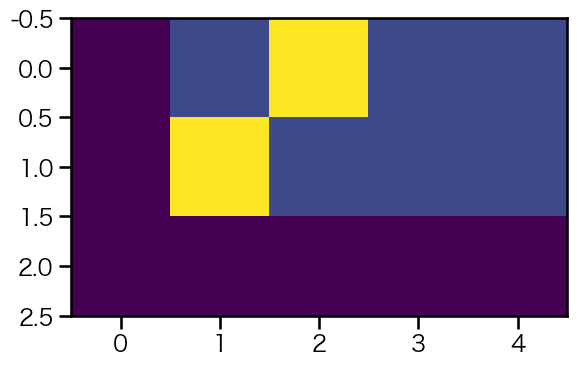

In [29]:
# 标签平滑示例。
crit = LabelSmoothing(5, 0, 0.4)
predict = torch.FloatTensor(
    [
        [0, 0.2, 0.7, 0.1, 0],
        [0, 0.2, 0.7, 0.1, 0],
        [0, 0.2, 0.7, 0.1, 0],
    ]
)
v = crit(predict.log(), torch.LongTensor([2, 1, 0]))

# 可视化标签平滑后的目标分布。
plt.imshow(crit.true_dist)
None

当模型对预测结果非常确定时，标签平滑会产生惩罚效果。

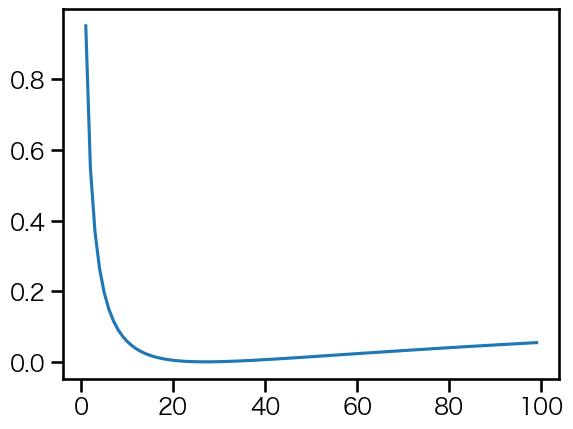

In [30]:
crit = LabelSmoothing(5, 0, 0.1)


def loss(x):
    """
    观察随着模型置信度提升，标签平滑损失如何变化。

    Args:
        x: 目标类别对应的相对分数。

    Returns:
        标量损失值。
    """
    d = x + 3 * 1
    predict = torch.FloatTensor([[0, x / d, 1 / d, 1 / d, 1 / d]])
    return crit(predict.log(), torch.LongTensor([1])).item()


plt.plot(np.arange(1, 100), [loss(x) for x in range(1, 100)])
None

## 一个简单的例子
我们通过一个简单的拷贝任务开始，随机产生一个序列，任务目标是重新生成相同的序列。

### 合成数据

In [31]:
def data_gen(V, batch_size, nbatches):
    """
    生成拷贝任务的随机数据。

    Args:
        V: 词表大小。
        batch_size: 每个 batch 的样本数 B。
        nbatches: batch 数量。

    Yields:
        Batch 对象，其中源序列和目标序列形状均为 (B, 10)。
    """
    for _ in range(nbatches):
        data = torch.randint(1, V, size=(batch_size, 10))
        data[:, 0] = 1
        src = data.requires_grad_(False).clone().detach()
        tgt = data.requires_grad_(False).clone().detach()
        yield Batch(src, tgt, 0)

### 损失函数定义

In [32]:
class SimpleLossCompute:
    """
    简单损失计算封装，与最新版 Annotated Transformer 的训练接口保持一致。

    Args:
        generator: 生成器模块，将隐藏状态映射到词表对数概率。
        criterion: 损失函数。
    """

    def __init__(self, generator, criterion):
        self.generator = generator
        self.criterion = criterion

    def __call__(self, x, y, norm):
        """
        Args:
            x: 模型输出隐藏状态，形状为 (B, T, D)。
            y: 监督标签，形状为 (B, T)。
            norm: 有效 token 数。

        Returns:
            loss_value: 标量损失值。
            sloss: 可用于反向传播的损失节点。
        """
        x = self.generator(x)
        sloss = (
            self.criterion(
                x.contiguous().view(-1, x.size(-1)), y.contiguous().view(-1)
            )
            / norm
        )
        return sloss.item() * norm, sloss

### 模型训练

In [33]:
# 在简单拷贝任务上训练一个两层 Transformer。
V = 11
criterion = LabelSmoothing(size=V, padding_idx=0, smoothing=0.0)
model = make_model(V, V, N=2)

optimizer = torch.optim.Adam(
    model.parameters(), lr=0.5, betas=(0.9, 0.98), eps=1e-9
)
lr_scheduler = LambdaLR(
    optimizer=optimizer,
    lr_lambda=lambda step: rate(
        step, model_size=model.src_embed[0].d_model, factor=1.0, warmup=400
    ),
)

batch_size = 80
for epoch in range(20):
    model.train()
    run_epoch(
        data_gen(V, batch_size, 20),
        model,
        SimpleLossCompute(model.generator, criterion),
        optimizer,
        lr_scheduler,
        mode="train",
    )
    model.eval()
    eval_loss = run_epoch(
        data_gen(V, batch_size, 5),
        model,
        SimpleLossCompute(model.generator, criterion),
        DummyOptimizer(),
        DummyScheduler(),
        mode="eval",
    )[0]
    print(eval_loss)

Epoch Step:      1 | Accumulation Step:   2 | Loss:   3.40 | Tokens / Sec:  2055.1 | Learning Rate: 5.5e-06
2.0191405773162843
Epoch Step:      1 | Accumulation Step:   2 | Loss:   2.07 | Tokens / Sec:  3105.6 | Learning Rate: 6.1e-05
1.6595807790756225
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.75 | Tokens / Sec:  3079.4 | Learning Rate: 1.2e-04
1.2998981714248656
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.48 | Tokens / Sec:  2715.8 | Learning Rate: 1.7e-04
0.8079252481460572
Epoch Step:      1 | Accumulation Step:   2 | Loss:   1.01 | Tokens / Sec:  2791.7 | Learning Rate: 2.3e-04
0.32638397216796877
Epoch Step:      1 | Accumulation Step:   2 | Loss:   0.50 | Tokens / Sec:  3077.2 | Learning Rate: 2.8e-04
0.11653850227594376
Epoch Step:      1 | Accumulation Step:   2 | Loss:   0.29 | Tokens / Sec:  3028.8 | Learning Rate: 3.4e-04
0.08934806287288666
Epoch Step:      1 | Accumulation Step:   2 | Loss:   0.20 | Tokens / Sec:  3109.2 | Learning Rate: 3.9e-04


### 贪婪解码
简单起见，直接采用贪婪算法进行解码。

In [34]:
def greedy_decode(model, src, src_mask, max_len, start_symbol):
    """
    使用贪婪策略逐步生成目标序列。

    Args:
        model: Transformer 模型。
        src: 源序列 token，形状为 (B, S)。这里示例中 B=1。
        src_mask: 源序列掩码，形状为 (B, 1, S)。
        max_len: 最大生成长度。
        start_symbol: 起始 token 索引。

    Returns:
        生成结果，形状为 (B, max_len)。
    """
    memory = model.encode(src, src_mask)
    ys = torch.zeros(1, 1).fill_(start_symbol).type_as(src.data)
    for _ in range(max_len - 1):
        out = model.decode(
            memory,
            src_mask,
            ys,
            subsequent_mask(ys.size(1)).type_as(src.data),
        )
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item()
        ys = torch.cat(
            [ys, torch.zeros(1, 1).type_as(src.data).fill_(next_word)], dim=1
        )
    return ys


model.eval()
src = torch.LongTensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])
max_len = src.shape[1]
src_mask = torch.ones(1, 1, max_len)
print(greedy_decode(model, src, src_mask, max_len=max_len, start_symbol=0))

tensor([[0, 2, 3, 4, 4, 5, 6, 7, 8, 9]])


### 可视化

编码器层 1


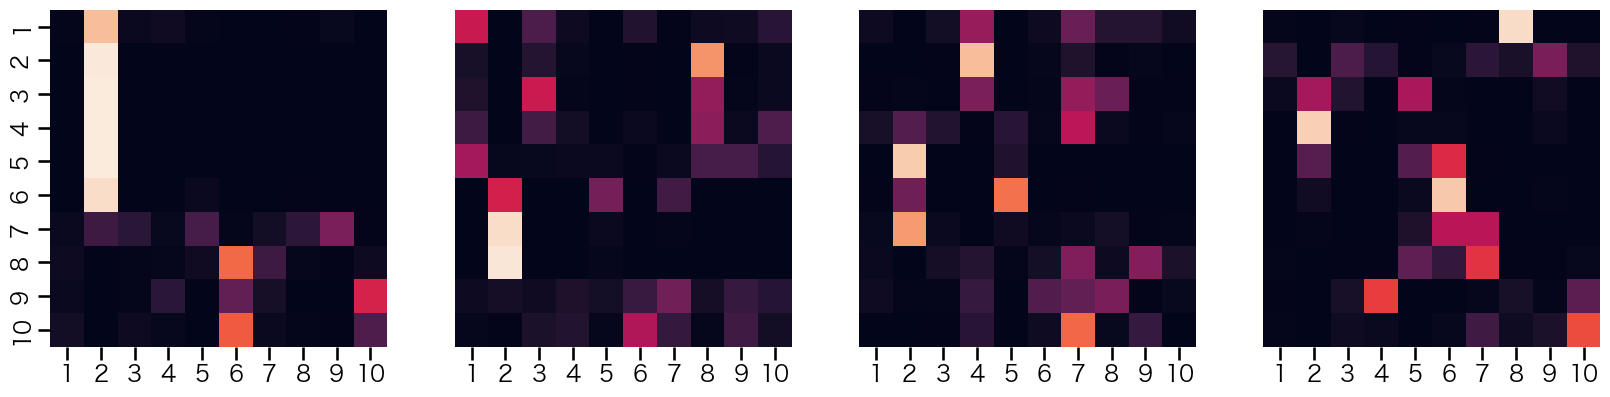

编码器层 2


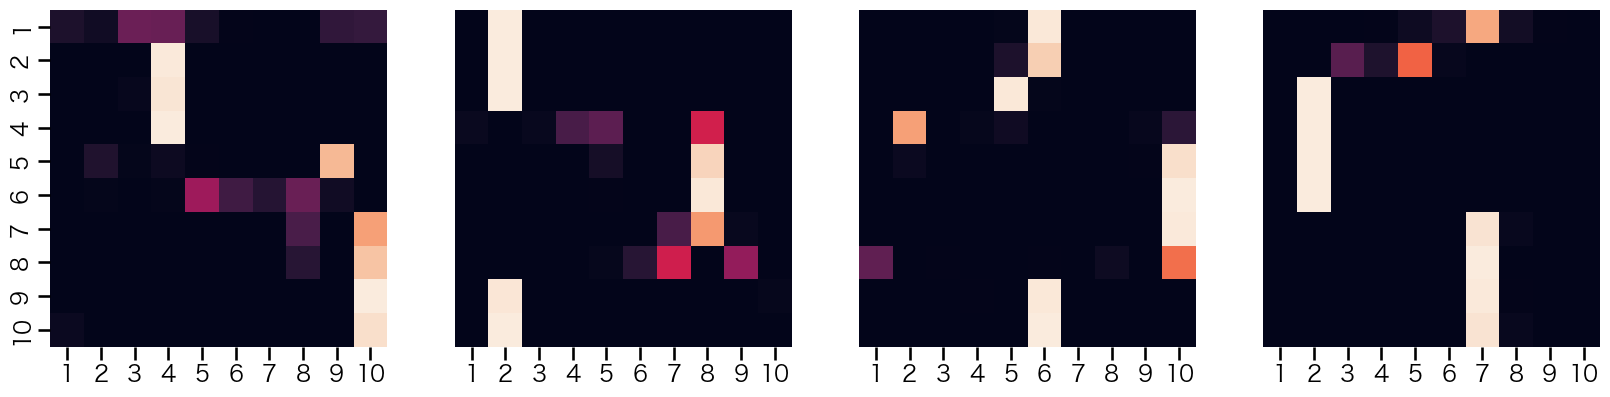

解码器自注意力层 1


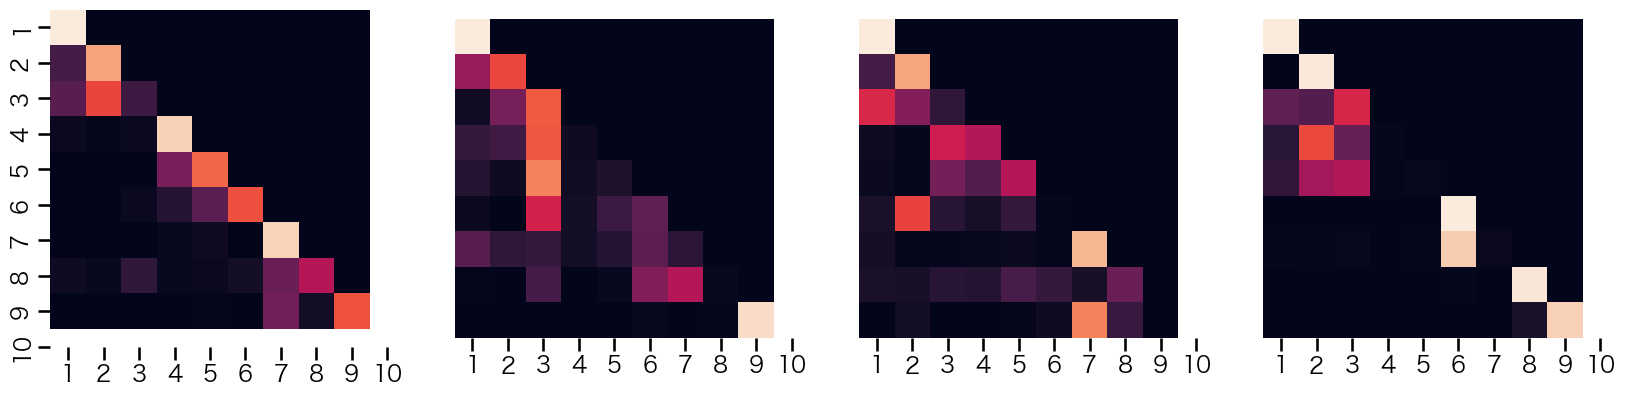

解码器交叉注意力层 1


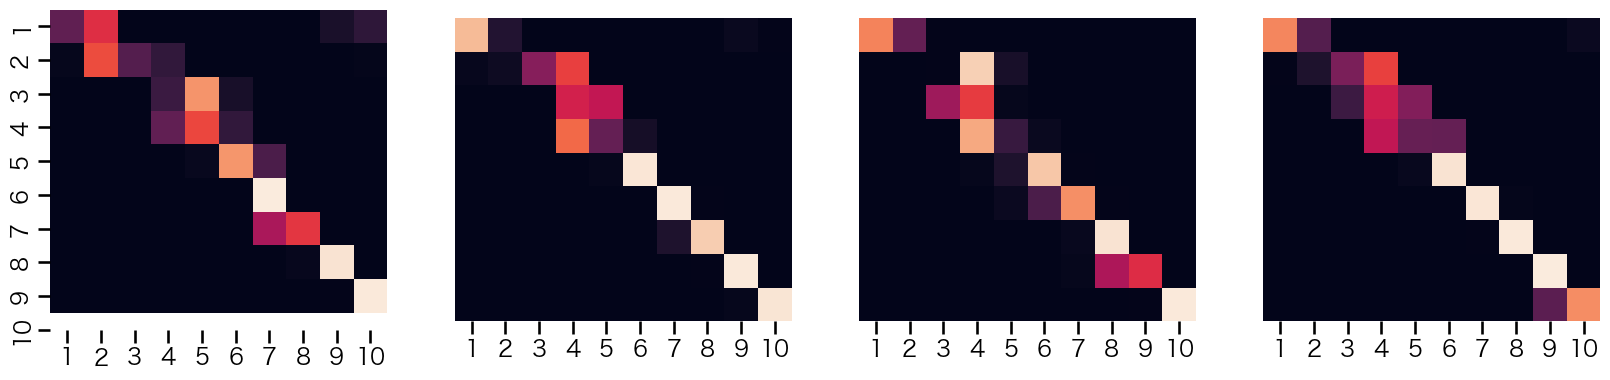

解码器自注意力层 2


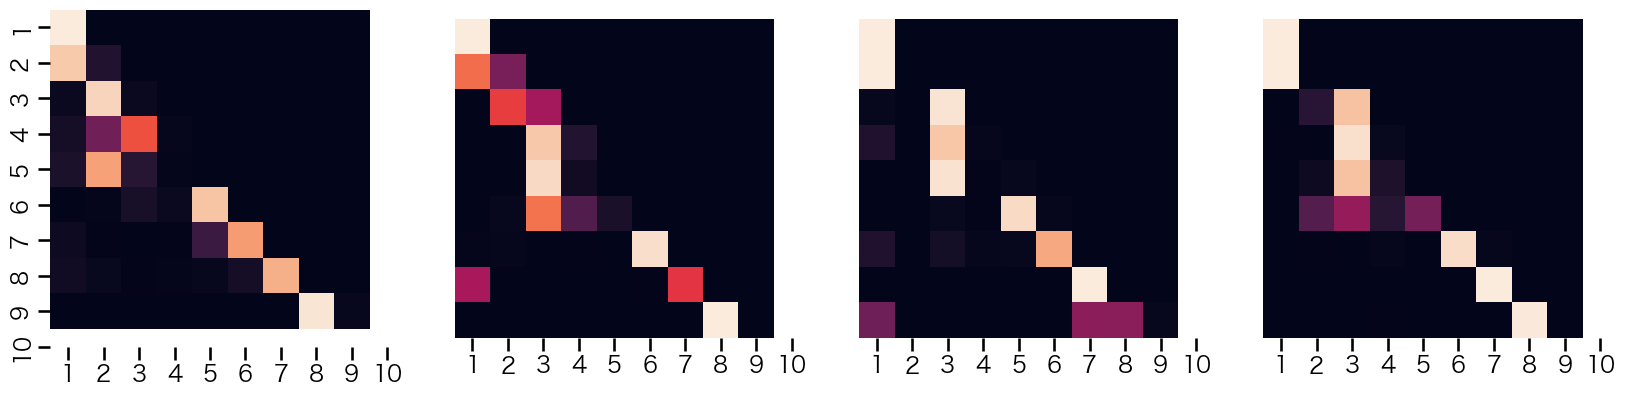

解码器交叉注意力层 2


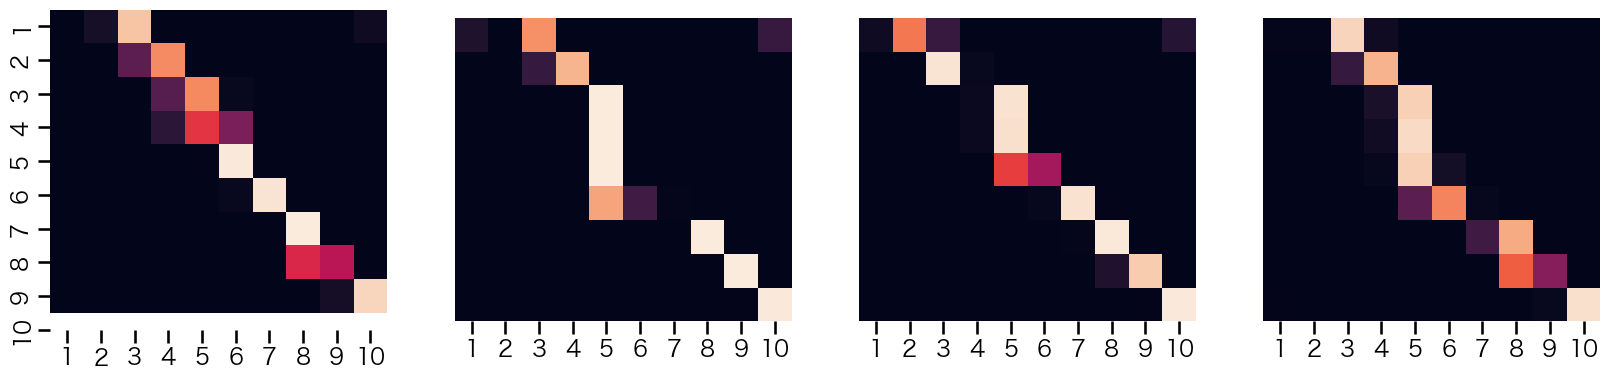

In [35]:
sent = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
tgt_sent = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


def draw(data, x, y, ax):
    """
    绘制单个注意力头的热力图。

    Args:
        data: 注意力矩阵，形状通常为 (Lq, Lk)。
        x: 横轴 token 标签列表，长度为 Lk。
        y: 纵轴 token 标签列表，长度为 Lq。
        ax: matplotlib 的坐标轴对象。
    """
    seaborn.heatmap(
        data,
        xticklabels=x,
        square=True,
        yticklabels=y,
        vmin=0.0,
        vmax=1.0,
        cbar=False,
        ax=ax,
    )


for layer in range(0, 2, 1):
    fig, axs = plt.subplots(1, 4, figsize=(20, 10))
    print("编码器层", layer + 1)
    for h in range(4):
        draw(
            model.encoder.layers[layer].self_attn.attn[0, h].detach(),
            sent,
            sent if h == 0 else [],
            ax=axs[h],
        )
    plt.show()

for layer in range(0, 2, 1):
    fig, axs = plt.subplots(1, 4, figsize=(20, 10))
    print("解码器自注意力层", layer + 1)
    for h in range(4):
        draw(
            model.decoder.layers[layer].self_attn.attn[0, h].detach()[
                : len(tgt_sent), : len(tgt_sent)
            ],
            tgt_sent,
            tgt_sent if h == 0 else [],
            ax=axs[h],
        )
    plt.show()
    print("解码器交叉注意力层", layer + 1)
    fig, axs = plt.subplots(1, 4, figsize=(20, 10))
    for h in range(4):
        draw(
            model.decoder.layers[layer].src_attn.attn[0, h].detach()[
                : len(tgt_sent), : len(sent)
            ],
            sent,
            tgt_sent if h == 0 else [],
            ax=axs[h],
        )
    plt.show()